**Mola dataset**

The MOLA dataset documents cases of returned looted antiquities, including their origin, trafficking routes, involved actors, and restitution. This script aims to get data from their API, and map the travel of artefacts.

In [3]:
import requests
from collections import defaultdict, Counter
import time
import csv
import pandas as pd
from pySankey.sankey import sankey
import matplotlib.pyplot as plt

BASE_URL = "https://mola.omeka.net/api/items"

# explore items content and element text parsed in order to choose the most appropriates

def fetch_items_page(page=1, per_page=50):
    params = {"page": page, "per_page": per_page}
    r = requests.get(BASE_URL, params=params, timeout=30)
    r.raise_for_status()
    return r.json()


def parse_element_texts(item):
    grouped = defaultdict(list)

    for entry in item.get("element_texts", []):
        field_name = entry.get("element", {}).get("name")
        text_value = entry.get("text")
        html_flag = entry.get("html", False)
        element_set = entry.get("element_set", {}).get("name")

        if not field_name:
            continue

        grouped[field_name].append({
            "text": text_value,
            "html": html_flag,
            "element_set": element_set
        })

    return dict(grouped)


def collect_all_keys(max_pages=None, sleep_seconds=0.2):
    page = 1
    field_counter = Counter()
    field_examples = defaultdict(list)
    parsed_items = []

    while True:
        items = fetch_items_page(page=page, per_page=50)

        if not items:
            break

        for item in items:
            parsed_fields = parse_element_texts(item)

            parsed_items.append({
                "item_id": item.get("id"),
                "url": item.get("url"),
                "fields": parsed_fields
            })

            for field_name, values in parsed_fields.items():
                field_counter[field_name] += 1

                # max 3 per field
                for v in values:
                    txt = v.get("text")
                    if txt and len(field_examples[field_name]) < 3:
                        if txt not in field_examples[field_name]:
                            field_examples[field_name].append(txt)

        print(f"Page {page} ran with ({len(items)} items)")
        page += 1

        if max_pages is not None and page > max_pages:
            break

        time.sleep(sleep_seconds)

    return parsed_items, field_counter, field_examples


if __name__ == "__main__":
    parsed_items, field_counter, field_examples = collect_all_keys(max_pages=5)

    print("\n--- Found fields ---")
    for field_name, count in field_counter.most_common():
        print(f"{field_name}: {count}")

    print("\n--- Content examples ---")
    for field_name, examples in field_examples.items():
        print(f"\n{field_name}")
        for ex in examples:
            print(f"  - {ex}")

Page 1 ran with (50 items)
Page 2 ran with (50 items)
Page 3 ran with (50 items)
Page 4 ran with (27 items)

--- Found fields ---
Title: 177
Object or Group Name: 172
Number of Objects: 172
Repatriated?: 172
Year Returned: 172
Case Summary: 172
Sending Country: 172
Receiving Country: 172
Reason for Return: 172
Sources: 172
MOLA Contributor(s): 172
Status: 172
Object Materials: 171
Country of Origin: 171
Peer Reviewed By: 171
Description of Object(s): 171
Object Type: 170
Returning Entity: 167
Creation Date: 167
Images: 167
Culture: 166
Size: 166
Findspot: 151
Date Looted: 150
Current Location: 139
Dealer: 119
Year Acquired: 114
Year of Last Price: 107
Museum Name: 106
Last Known Price, Valuation or Estimate: 106
Value in 2024 US Dollars: 105
Museum Donation or Purchase?: 104
Criminal Behaviors Alleged: 98
Research Notes: 97
Alleged Looter: 91
Alleged Smuggler: 91
Law Enforcement Entity: 89
Documents: 88
Alternate Name(s): 86
Private Collector: 83
See Also: 83
Expert Review: 83
Image Ca

Based on both objectives (temporal trajectory map) and most complete text elements, we selected 17 fields.
| Field                     | Count |
|---------------------------|-------|
| Title                     | 177   |
| Repatriated?              | 172   |
| Year Returned             | 172   |
| Sending Country           | 172   |
| Receiving Country         | 172   |
| Object Materials          | 171   |
| Country of Origin         | 171   |
| Description of Object(s)  | 171   |
| Object Type               | 170   |
| Culture                   | 166   |
| Size                      | 166   |
| Findspot                  | 151   |
| Date Looted               | 150   |
| Current Location          | 139   |
| Dealer                    | 119   |
| Year Acquired             | 114   |
| Museum Name               | 106   |

In [4]:
import pandas as pd
# Chosen fields for filtering text elements (name, text)
FIELDS = [
    "Title", "Repatriated?", "Year Returned", "Sending Country",
    "Receiving Country", "Object Materials", "Country of Origin",
    "Description of Object(s)", "Object Type", "Culture", "Size",
    "Findspot", "Date Looted", "Current Location", "Dealer",
    "Year Acquired", "Museum Name"
]

def parse_item(item):
    data = defaultdict(list) #allows to store several values

    for entry in item.get("element_texts", []): #browse all text elements and get key:value
        name = entry.get("element", {}).get("name")
        text = entry.get("text")

        if name in FIELDS and text:
            data[name].append(text)

    # string if one value otherwise join)
    result = {}
    for f in FIELDS:
        vals = data.get(f)
        if not vals:
            result[f] = None
        elif len(vals) == 1:
            result[f] = vals[0]
        else:
            result[f] = " | ".join(vals)

    return result


def fetch_all():
    page = 1
    rows = []

    while True:
        r = requests.get(BASE_URL, params={"page": page, "per_page": 50}, timeout=30)
        items = r.json()

        if not items:
            break

        for item in items:
            parsed = parse_item(item)
            parsed["id"] = item["id"]
            rows.append(parsed)

        print(f"page {page}")
        page += 1
        time.sleep(0.2)

    return rows


rows = fetch_all()

# CSV export
with open("../data/raw/mola_extraction.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["id"] + FIELDS)
    writer.writeheader()
    writer.writerows(rows)

page 1
page 2
page 3
page 4


In [5]:
df_mola =  pd.DataFrame(rows)
#df_mola.head(5)

In [6]:
summary = pd.DataFrame({
    "unique_values": df_mola.nunique(dropna=False),
    "missing_values": df_mola.isna().sum()}).sort_values(by = "unique_values", ascending=True)
#print(summary) -> many content apper like lists with | however are str

In [7]:
# check if these two fields have the same values (and they have)
((df_mola["Receiving Country"] == df_mola["Country of Origin"]) & df_mola["Receiving Country"].notna()).sum()

np.int64(161)

In [8]:
# explore unique values for each categorical column
cols = ["Repatriated?", "Size", "Sending Country", "Country of Origin","Receiving Country", "Year Returned", "Object Type",
"Object Materials", "Museum Name", "Year Acquired", "Date Looted"]

#for col in cols:
    #print(f"\n{col}")
    #print(df_mola[col].dropna().unique())

# many different unique values, appaearing as lists while strings. 

In [9]:
# additional filtering and extraction of the first word - arbitrary choice
df_mola_final = df_mola.copy()
final_cols = ["Sending Country", "Receiving Country", "Year Returned", "Object Type",
"Object Materials", "Year Acquired", "Date Looted"]
for col in final_cols:
    df_mola_final[col] = df_mola_final[col].str.split("|").str[0].str.strip()
    print(f"\n{col}")
    print(df_mola_final[col].dropna().unique())


Sending Country
['USA' 'Switzerland' 'UK' 'Germany' 'Australia' 'Canada' 'China' 'France'
 'Greece' 'Italy' 'Sweden' 'Belgium' 'Argentina' 'Netherlands' 'Thailand']

Receiving Country
['Italy' 'Iraq' 'Greece' 'Türkiye' 'Albania' 'Romania' 'Thailand' 'Iran'
 'Nigeria' 'Costa Rica' 'India' 'Cambodia' 'Pakistan' 'USA' 'Cyprus'
 'Yemen' 'Peru' 'Guatemala' 'Mexico' 'Lebanon' 'Libya' 'Hungary' 'Syria'
 'Armenia' 'China' 'Afghanistan' 'Ethiopia' 'Canada' 'Egypt' 'Nepal'
 'Vietnam' 'Ghana' 'UK' 'Saudi Arabia' 'Spain' 'Haiti' 'Sri Lanka']

Year Returned
['2006' '2012' '2010' '2008' '2005' '2007' '1999' '2011' '1996' '2014'
 '1952' '2000' '2013' '1988' '2020' '2016' '2015' '1992' '1976' '2001'
 '1991' '2004' '2022' '2021' '2023' '2017; 2021; 2022; 2025; 2026' '2002'
 '2018' '2017' '1982' '2009' '2003' '2024' '2019' '1993'
 'Between 1980 and 2019' '2016 (MHA Nation, North Dakota, United States)'
 '2006 (273 objects retuned to Peru)' 'Various' '1986' '1998' '2025']

Object Type
['Sculpture – stat

In [20]:
cols_num = "Year Returned","Year Acquired","Date Looted"
for col in cols_num:
    df_mola_final[col] = pd.to_numeric(df_mola_final[col], errors="coerce") #convert & clean
    print(f"\n{col}")
    print(df_mola_final[col].dropna().unique())


Year Returned
[2006. 2012. 2010. 2008. 2005. 2007. 1999. 2011. 1996. 2014. 1952. 2000.
 2013. 1988. 2020. 2016. 2015. 1992. 1976. 2001. 1991. 2004. 2022. 2021.
 2023. 2002. 2018. 2017. 1982. 2009. 2003. 2024. 2019. 1993. 1986. 1998.
 2025.]

Year Acquired
[1992. 1986. 1977. 1996. 1981. 1990. 1983. 1985. 1972. 1993. 1984. 1948.
 1982. 1966. 1967. 1991. 1979. 2014. 1932. 2016. 1999. 2000. 1973. 2006.
 1988. 1976. 1968. 2010. 2007. 2008. 1975. 1937. 1935. 1929. 1980. 2005.
 1997. 1989. 2011. 2012. 1965. 2002. 2001. 2019. 1971. 1978. 2017. 1927.
 1939. 2024.]

Date Looted
[1980. 2003. 1976. 1988. 1971. 1981. 1960. 2001. 1990. 1982. 1956. 1899.
 1911. 1936. 2008. 2006. 1964. 1860. 1991. 1937. 1928. 1984. 1994. 1897.
 1967. 1874. 2000. 1962. 2007. 1979. 1974. 1975. 2011. 1765. 1943. 1944.]


In [10]:
df_mola_final["Object Type"] = df_mola_final["Object Type"].str.split(" – ").str[0].str.strip()
#print(df_mola_final["Object Type"].dropna().unique())

In [11]:
df_mola_final = df_mola_final[["id", "Object Type", "Object Materials", "Sending Country", "Receiving Country","Year Returned","Year Acquired","Date Looted"]]
df_mola_final.columns = df_mola_final.columns.str.strip().str.lower().str.replace(" ","_")
#df_mola_final.value_counts
#df_mola_final.dtypes

In [12]:
#df_mola_final.to_csv("../data/raw/mola_artefacts.csv", sep = ';', index = False, encoding = "utf-8")

Text(0.5, 1.0, 'Flows of returned trafficked artefacts')

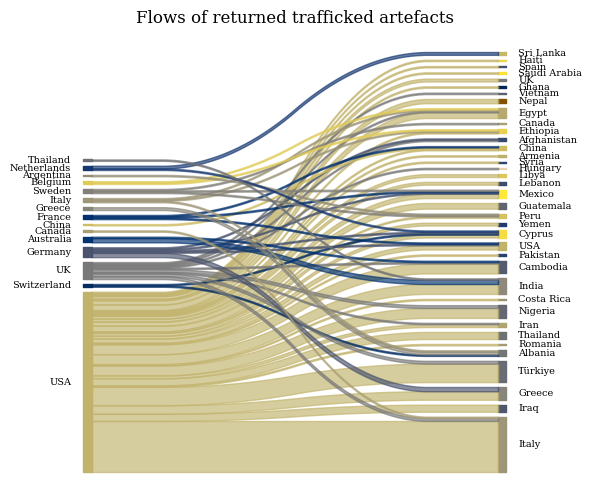

In [45]:


df = df_mola_final[df_mola_final["sending_country"].notna() & df_mola_final["receiving_country"].notna()]

# toutes les catégories uniques
labels = list(set(df["sending_country"]).union(set(df["receiving_country"])))

cmap = plt.get_cmap("cividis", len(labels))
base_colors = [cmap(i) for i in range(len(labels))]

accent = "#825000"        # marron
beige = "#E6D3B3"         # beige doux

n = len(base_colors)

if n > 2:
    base_colors[0] = accent          # début (gauche)
    base_colors[n // 2] = beige      # milieu

colors = {label: base_colors[i] for i, label in enumerate(labels)}

sankey(df["sending_country"], df["receiving_country"], aspect=40, colorDict=colors, fontsize=7)

plt.savefig("../figures/trafficked_artefacts_returns_flows.png", dpi=300, bbox_inches="tight")
plt.title("Flows of returned trafficked artefacts")

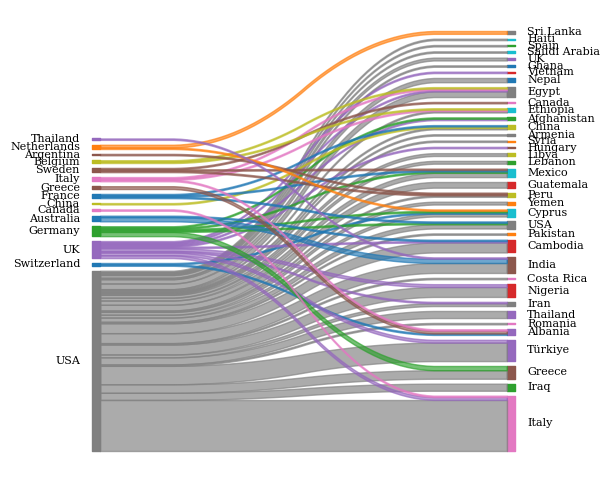

In [28]:
sankey(
    df["sending_country"],
    df["receiving_country"],
    aspect=30,
    colorDict=colors,
    fontsize=8,
)